INFO:__main__:Building Figure S1: GLORYS12 sea ice evaluation
INFO:__main__:Loading saved export data...
INFO:__main__:Loading saved SIT data...
INFO:__main__:Loading saved speed data...
INFO:__main__:  Speed merge: 336 OSI-455 months, 56 gap-filled from OSI-405 (161 total OSI-405 months)
INFO:__main__:Figure saved: ./outputs/figures/figure_s01_glorys12_sea_ice_verification.png


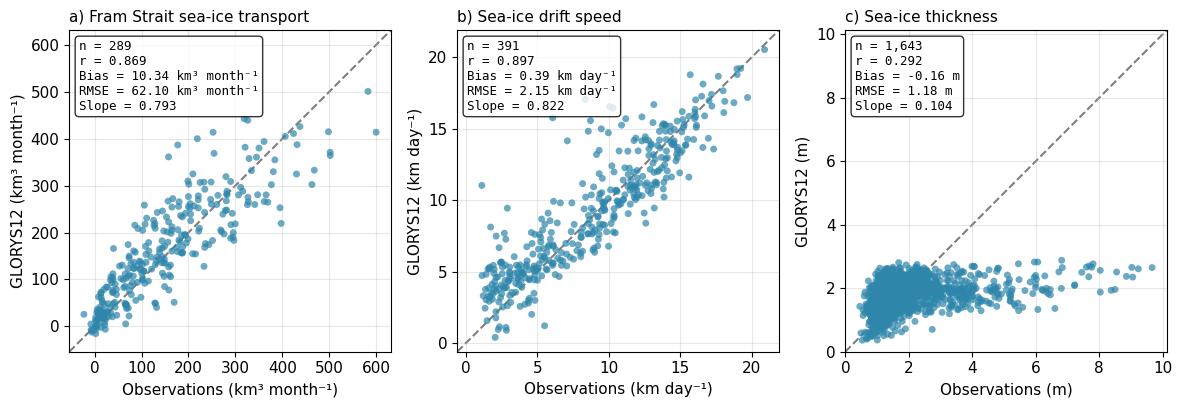

INFO:__main__:Methodology saved: ./outputs/methods/figure_s01_methodology.md
INFO:__main__:Panel (a) stats: n=289, r=0.869, bias=10.34, RMSE=62.10, slope=0.793
INFO:__main__:Panel (b) stats: n=391, r=0.897, bias=0.39, RMSE=2.15, slope=0.822
INFO:__main__:Panel (c) stats: n=1643, r=0.292, bias=-0.162, RMSE=1.177, slope=0.104
INFO:__main__:Figure S1 complete.



FIGURE S1 — SUMMARY STATISTICS

(a) Fram Strait sea ice export
  n=289, r=0.869, bias=10.34 km³ month⁻¹, RMSE=62.10 km³ month⁻¹, slope=0.793

(b) Greenland Sea sea ice drift speed
  n=391, r=0.897, bias=0.39 km day⁻¹, RMSE=2.15 km day⁻¹, slope=0.822

(c) Sea ice thickness
  n=1643, r=0.292, bias=-0.162 m, RMSE=1.177 m, slope=0.104
  Months processed: 84
  Period: 2010-11 to 2024-04



In [2]:
"""
Figure S1: GLORYS12 Sea Ice Evaluation
=======================================

Three-panel scatter plot evaluation of GLORYS12 sea ice against observations:

  (a) Sea ice volume export at Fram Strait — De Steur et al. mooring obs
  (b) Greenland Sea sea ice drift speed — OSISAF (OSI-455 priority, OSI-405 gap-fill)
  (c) Sea ice thickness — ESA CCI / AWI CryoSat-2 L3 (status_flag==0, quality_flag==0)
      Collocated per grid cell: each point is one valid CCI grid cell paired
      with the nearest GLORYS12 grid cell for the same month.

Outputs:
  - Figure:         ./outputs/figures/figure_s01_glorys12_sea_ice_verification.png
  - Processed data: ./outputs/processed_data/figure_s01/
  - Methodology:    ./outputs/methods/figure_s01_methodology.md
  - Log:            ./outputs/logs/figure_s01.log

Version:       1.1.0
Last Modified: 22-06-2026
Author:        Chris Barrell

"""

import sys
import os
import glob
import math
import logging

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy import stats

sys.path.append('..')
try:
    from utils.logger import get_logger
    logger = get_logger(__name__, config_path='../config.yaml')
except Exception:
    logger = logging.getLogger(__name__)
    logging.basicConfig(level=logging.INFO)

# ============================================================================
# CONFIGURATION
# ============================================================================

REPROCESS = False  # Set True to reprocess from source files

# --- Paths ---
GLORYS_PATH          = '../../glorys12_with_density/glorys12_*_Greenland_Sea_with_density.nc'
OBS_EXPORT_FILE      = '../../from_laura/monthly_mean_FS_seaicevolume_flux_1990to2020.txt'
SIT_DIR              = '/local/jbj13rpu/Documents/ROVER/sea_ice_thickness/envisat_cryosat/'
SIT_PATTERN          = 'ice_thickness_nh_ease2-250_*dr-v3p0_*.nc'

OUTPUT_DIR           = './outputs/figures/'
PROCESSED_DIR        = './outputs/processed_data/figure_s01/'
OUTPUT_METHODS_DIR   = './outputs/methods/'
LOG_DIR              = './outputs/logs/'

for d in [OUTPUT_DIR, PROCESSED_DIR, OUTPUT_METHODS_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Add file handler to logger ---
log_path = os.path.join(LOG_DIR, 'figure_s01.log')
file_handler = logging.FileHandler(log_path, mode='w')
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))
logger.addHandler(file_handler)

PROCESSED_EXPORT_CSV = PROCESSED_DIR + 'export_comparison.csv'
PROCESSED_SPEED_CSV  = PROCESSED_DIR + 'velocity_comparison_latlon_final.csv'
PROCESSED_SIT_CSV    = PROCESSED_DIR + 'sit_comparison.csv'

# --- Domain ---
GREENLAND_SEA_COORDS = [
    (-22, 71), (-8.5, 71), (12, 79), (-21, 79), (-28, 73), (-22, 71)
]

# --- Fram Strait transect ---
FS_LAT     = 79
FS_LON_MIN = -20
FS_LON_MAX = 12

# --- SIT flags ---
SIT_STATUS_NOMINAL  = 0   # nominal_retrieval
SIT_QUALITY_NOMINAL = 0   # nominal_quality

# --- Style (project conventions) ---
COLOR_OBS    = 'black'
COLOR_GLORYS = '#2E86AB'
FONTSIZE     = 11
STATS_FS     = 9
LEGEND_FS    = 10

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = (math.radians(x) for x in [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def days_in_month(time_array):
    if hasattr(time_array, 'to_index'):
        time_array = time_array.to_index()
    return time_array.days_in_month


def remove_nan_pairs(*arrays):
    """Remove rows where any array has NaN. Returns numpy arrays."""
    arrays = [a.values if hasattr(a, 'values') else np.asarray(a) for a in arrays]
    valid = np.ones(len(arrays[0]), dtype=bool)
    for a in arrays:
        valid &= np.isfinite(a)
    return tuple(a[valid] for a in arrays)


def calc_stats(obs, model):
    """Pearson r, bias, RMSE, slope for a model-observation pair."""
    obs_c, model_c = remove_nan_pairs(obs, model)
    if len(obs_c) < 3:
        return None
    corr, p_corr = stats.pearsonr(obs_c, model_c)
    slope, intercept, r_val, _, _ = stats.linregress(obs_c, model_c)
    return {
        'n':     len(obs_c),
        'corr':  corr,
        'p':     p_corr,
        'bias':  float(np.mean(model_c - obs_c)),
        'rmse':  float(np.sqrt(np.mean((model_c - obs_c)**2))),
        'slope': slope,
        'r2':    r_val**2,
    }


def make_gs_mask(lon2d, lat2d):
    """Boolean mask for the Greenland Sea polygon on a 2-D grid."""
    poly = Path(GREENLAND_SEA_COORDS)
    pts  = np.column_stack([lon2d.ravel(), lat2d.ravel()])
    return poly.contains_points(pts).reshape(lon2d.shape)


def add_stats_box(ax, stats_dict, units):
    p_str = '< 0.001' if stats_dict['p'] < 0.001 else f'= {stats_dict["p"]:.3f}'
    txt = (
        f'n = {stats_dict["n"]:,}\n'
        f'r = {stats_dict["corr"]:.3f}\n' # (p {p_str})
        f'Bias = {stats_dict["bias"]:.2f} {units}\n'
        f'RMSE = {stats_dict["rmse"]:.2f} {units}\n'
        f'Slope = {stats_dict["slope"]:.3f}'
    )
    ax.text(0.03, 0.97, txt, transform=ax.transAxes, fontsize=STATS_FS,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def add_11_line(ax):
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, zorder=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')


# ============================================================================
# PANEL (a): FRAM STRAIT EXPORT
# ============================================================================

def process_export():
    logger.info('Processing Fram Strait export...')

    # --- Observations ---
    df = pd.read_csv(OBS_EXPORT_FILE, skiprows=2,
                     names=['year', 'month', 'ice_vol_flux'], header=None)
    df['time'] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
    df = df.set_index('time').sort_index()
    da_obs = -df['ice_vol_flux'].to_xarray().astype(float)

    # --- GLORYS12 ---
    ds_g = xr.open_mfdataset(GLORYS_PATH, parallel=False)
    fs   = ds_g.sel(longitude=slice(FS_LON_MIN, FS_LON_MAX))
    fs   = fs.sel(latitude=FS_LAT, method='nearest')

    x_dist = haversine_distance(
        float(fs.latitude), float(fs.longitude[0]),
        float(fs.latitude), float(fs.longitude[1])
    )

    vol_per_cell = fs.siconc * fs.sithick * fs.vsi * (x_dist * 1000)
    total_ms     = vol_per_cell.sum(dim='longitude')
    spm          = days_in_month(total_ms.time) * 86400
    da_glorys    = -total_ms * spm / 1e9

    # --- Overlap ---
    t0 = max(da_obs.time.min().values, da_glorys.time.min().values)
    t1 = min(da_obs.time.max().values, da_glorys.time.max().values)
    obs_ov   = da_obs.sel(time=slice(t0, t1))
    glor_ov  = da_glorys.sel(time=slice(t0, t1))
    glor_mat = glor_ov.interp(time=obs_ov.time, method='nearest')

    df_out = pd.DataFrame({
        'time':   obs_ov.time.values,
        'obs':    obs_ov.values,
        'glorys': glor_mat.values,
    })
    df_out.to_csv(PROCESSED_EXPORT_CSV, index=False)
    logger.info(f'  Export CSV saved: {PROCESSED_EXPORT_CSV}')
    return df_out


def load_export():
    if not REPROCESS and os.path.exists(PROCESSED_EXPORT_CSV):
        logger.info('Loading saved export data...')
        return pd.read_csv(PROCESSED_EXPORT_CSV, parse_dates=['time'])
    return process_export()


# ============================================================================
# PANEL (b): SEA ICE SPEED — OSI-455 priority, OSI-405 gap-fill
# ============================================================================

def load_speed():
    """Load and merge speed data: OSI-455 priority, OSI-405 where OSI-455 absent."""
    if not os.path.exists(PROCESSED_SPEED_CSV):
        raise FileNotFoundError(
            f'Speed CSV not found: {PROCESSED_SPEED_CSV}\n'
            'Ensure velocity_comparison_latlon_final.csv is in PROCESSED_DIR.'
        )
    logger.info('Loading saved speed data...')
    df = pd.read_csv(PROCESSED_SPEED_CSV, parse_dates=['time'])

    # Build merged series: OSI-455 where available, OSI-405 to fill gaps
    obs_455    = df.get('speed_obs_455',    pd.Series(np.nan, index=df.index))
    glorys_455 = df.get('speed_glorys_455', pd.Series(np.nan, index=df.index))
    obs_405    = df.get('speed_obs_405',    pd.Series(np.nan, index=df.index))
    glorys_405 = df.get('speed_glorys_405', pd.Series(np.nan, index=df.index))

    obs_merged    = obs_455.where(obs_455.notna(),    other=obs_405)
    glorys_merged = glorys_455.where(glorys_455.notna(), other=glorys_405)

    # Log coverage
    n_455  = obs_455.notna().sum()
    n_405  = obs_405.notna().sum()
    n_fill = (obs_455.isna() & obs_405.notna()).sum()
    logger.info(f'  Speed merge: {n_455} OSI-455 months, '
                f'{n_fill} gap-filled from OSI-405 ({n_405} total OSI-405 months)')

    df_merged = pd.DataFrame({
        'time':   df['time'],
        'obs':    obs_merged.values,
        'glorys': glorys_merged.values,
    })
    return df_merged


# ============================================================================
# PANEL (c): SEA ICE THICKNESS — collocated per grid cell
# ============================================================================

def process_sit():
    logger.info('Processing SIT comparison...')

    ds_g  = xr.open_mfdataset(GLORYS_PATH, parallel=False)
    g_lat = ds_g.latitude.values
    g_lon = ds_g.longitude.values

    sit_files = sorted(glob.glob(os.path.join(SIT_DIR, SIT_PATTERN)))
    if not sit_files:
        raise FileNotFoundError(
            f'No SIT files found matching: {os.path.join(SIT_DIR, SIT_PATTERN)}'
        )
    logger.info(f'  Found {len(sit_files)} SIT files')

    records = []

    for fpath in sit_files:
        fname  = os.path.basename(fpath)
        yyyymm = fname.split('_')[-1].replace('.nc', '')
        year   = int(yyyymm[:4])
        month  = int(yyyymm[4:])

        # Winter season only
        if month not in [10, 11, 12, 1, 2, 3, 4]:
            continue

        ds_sit  = xr.open_dataset(fpath)

        # CryoSat-2 only — skip Envisat files
        if ds_sit.attrs.get('platform', '').lower() != 'cryosat-2':
            logger.info(f'  {yyyymm}: skipping ({ds_sit.attrs.get("platform", "unknown")} data)')
            ds_sit.close()
            continue
        
        sit_raw = ds_sit['sea_ice_thickness'].values.squeeze()
        sflag   = ds_sit['status_flag'].values.squeeze()
        qflag   = ds_sit['quality_flag'].values.squeeze()
        lat_sit = ds_sit['lat'].values
        lon_sit = ds_sit['lon'].values
        ds_sit.close()

        # --- Masking: strict flags, finite, positive ---
        valid = (
            (sflag == SIT_STATUS_NOMINAL) &
            (qflag == SIT_QUALITY_NOMINAL) &
            np.isfinite(sit_raw) &
            (sit_raw > 0)
        )

        # --- Greenland Sea mask on CCI grid ---
        gs_mask_sit = make_gs_mask(lon_sit, lat_sit)
        valid_gs    = valid & gs_mask_sit
        n_valid     = int(np.sum(valid_gs))

        if n_valid < 5:
            logger.info(f'  {yyyymm}: insufficient valid SIT points ({n_valid}), skipping')
            continue

        # --- GLORYS12 for same month ---
        try:
            ds_month   = ds_g.sel(time=f'{year:04d}-{month:02d}', method='nearest')
            glorys_sit = ds_month['sithick'].values
            if glorys_sit.ndim == 3:
                glorys_sit = glorys_sit[0]
        except Exception:
            logger.info(f'  {yyyymm}: no GLORYS12 data, skipping')
            continue

        # --- Nearest neighbour lookup for each valid CCI point ---
        cci_lats = lat_sit[valid_gs]
        cci_lons = lon_sit[valid_gs]
        cci_sits = sit_raw[valid_gs]

        glorys_vals = np.full(n_valid, np.nan)
        for i in range(n_valid):
            i_lat = np.argmin(np.abs(g_lat - cci_lats[i]))
            i_lon = np.argmin(np.abs(g_lon - cci_lons[i]))
            glorys_vals[i] = glorys_sit[i_lat, i_lon]

        # --- Store all valid collocated pairs for this month ---
        n_pairs = 0
        for i in range(n_valid):
            if np.isfinite(glorys_vals[i]):
                records.append({
                    'time':       pd.Timestamp(year=year, month=month, day=1),
                    'cci_sit':    float(cci_sits[i]),
                    'glorys_sit': float(glorys_vals[i]),
                    'lat':        float(cci_lats[i]),
                    'lon':        float(cci_lons[i]),
                })
                n_pairs += 1

        logger.info(
            f'  {yyyymm}: {n_pairs} collocated pairs, '
            f'CCI mean={np.mean(cci_sits):.3f} m, '
            f'GLORYS mean={np.nanmean(glorys_vals):.3f} m'
        )

    if not records:
        raise ValueError('No valid SIT records found — check file paths and date range')

    df_out = pd.DataFrame(records)
    df_out.to_csv(PROCESSED_SIT_CSV, index=False)
    logger.info(f'  SIT CSV saved: {PROCESSED_SIT_CSV}')
    return df_out


def load_sit():
    if not REPROCESS and os.path.exists(PROCESSED_SIT_CSV):
        logger.info('Loading saved SIT data...')
        return pd.read_csv(PROCESSED_SIT_CSV, parse_dates=['time'])
    return process_sit()


# ============================================================================
# METHODOLOGY
# ============================================================================

def write_methodology(st_export, st_speed, st_sit):
    lines = [
        '# Figure S1 — Methodology',
        '',
        '## Overview',
        'GLORYS12 sea ice is evaluated against three independent observational '
        'datasets using monthly scatter comparisons.',
        '',
        '## Panel (a): Fram Strait sea ice export',
        '- **Observations**: De Steur et al. mooring-based monthly sea ice volume '
        'flux estimates at Fram Strait (79°N, 20°W–12°E).',
        '- **GLORYS12**: Sea ice volume transport computed as the integral of '
        '`siconc × sithick × vsi` across the Fram Strait transect at 79°N. '
        'Grid cell widths computed using the Haversine formula. '
        'Transport converted from m³ s⁻¹ to km³ month⁻¹ using actual days per month. '
        'Sign convention: positive = southward (export).',
        '- **Comparison**: Overlapping period only; GLORYS12 interpolated to '
        'observation time steps using nearest-neighbour matching.',
        '',
        '## Panel (b): Greenland Sea sea ice drift speed',
        '- **Observations**: OSISAF sea ice drift products OSI-455 (primary) and '
        'OSI-405 (gap-fill where OSI-455 is unavailable), pre-processed to '
        'Greenland Sea monthly mean speed (km day⁻¹).',
        '- **GLORYS12**: Collocated monthly mean speed from the same domain.',
        '- **Merging**: OSI-455 is used preferentially; OSI-405 fills months '
        'with no OSI-455 data to avoid double-counting the overlapping period.',
        '- **Sign corrections**: u-component sign correction applied throughout '
        'for OSI-405; v-component sign correction applied for 2009-12 to 2015-05.',
        '',
        '## Panel (c): Sea ice thickness',
        '- **Observations**: ESA CCI / AWI CryoSat-2 L3 sea ice thickness, '
        'filtered to status_flag == 0 (nominal retrieval) and '
        'quality_flag == 0 (nominal quality). Negative values excluded.',
        '- **GLORYS12**: `sithick` extracted at the nearest grid cell to each '
        'valid CCI observation point for the same month.',
        '- **Domain**: Greenland Sea polygon. Winter months only (October–April).',
        '- **Scatter**: Each point represents one valid CCI grid cell collocated '
        'with the nearest GLORYS12 grid cell.',
        '',
        '## Statistics',
        'Pearson correlation (r), bias (GLORYS12 − observations), RMSE, and '
        'linear regression slope computed over all valid pairs. '
        'Significance threshold: p < 0.001.',
        '',
    ]

    if st_export:
        p_str = '< 0.001' if st_export['p'] < 0.001 else f'= {st_export["p"]:.3f}'
        lines += [
            '## Panel (a) statistics',
            f'- n = {st_export["n"]}',
            f'- r = {st_export["corr"]:.3f} (p {p_str})',
            f'- Bias = {st_export["bias"]:.2f} km³ month⁻¹',
            f'- RMSE = {st_export["rmse"]:.2f} km³ month⁻¹',
            f'- Slope = {st_export["slope"]:.3f}',
            '',
        ]

    if st_speed:
        p_str = '< 0.001' if st_speed['p'] < 0.001 else f'= {st_speed["p"]:.3f}'
        lines += [
            '## Panel (b) statistics (OSI-455 priority merge)',
            f'- n = {st_speed["n"]}',
            f'- r = {st_speed["corr"]:.3f} (p {p_str})',
            f'- Bias = {st_speed["bias"]:.2f} km day⁻¹',
            f'- RMSE = {st_speed["rmse"]:.2f} km day⁻¹',
            f'- Slope = {st_speed["slope"]:.3f}',
            '',
        ]

    if st_sit:
        p_str = '< 0.001' if st_sit['p'] < 0.001 else f'= {st_sit["p"]:.3f}'
        lines += [
            '## Panel (c) statistics',
            f'- n = {st_sit["n"]}',
            f'- r = {st_sit["corr"]:.3f} (p {p_str})',
            f'- Bias = {st_sit["bias"]:.3f} m',
            f'- RMSE = {st_sit["rmse"]:.3f} m',
            f'- Slope = {st_sit["slope"]:.3f}',
            '',
        ]

    method_path = os.path.join(OUTPUT_METHODS_DIR, 'figure_s01_methodology.md')
    with open(method_path, 'w') as f:
        f.write('\n'.join(lines))
    logger.info(f'Methodology saved: {method_path}')


# ============================================================================
# MAIN: BUILD FIGURE S1
# ============================================================================


logger.info('Building Figure S1: GLORYS12 sea ice evaluation')

# --- Load data ---
df_export = load_export()
df_sit    = load_sit()

try:
    df_speed = load_speed()
    speed_available = True
except FileNotFoundError as e:
    logger.warning(str(e))
    speed_available = False

# --- Figure layout: 1 row, 3 panels ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ----------------------------------------------------------------
# Panel (a): Fram Strait export
# ----------------------------------------------------------------
ax = axes[0]

obs_c, glorys_c = remove_nan_pairs(df_export['obs'], df_export['glorys'])
ax.scatter(obs_c, glorys_c,
           c=COLOR_GLORYS, s=25, alpha=0.7, edgecolors='none', zorder=2)

add_11_line(ax)

st_export = calc_stats(obs_c, glorys_c)
if st_export:
    add_stats_box(ax, st_export, 'km³ month⁻¹')

ax.set_xlabel('Observations (km³ month⁻¹)', fontsize=FONTSIZE)
ax.set_ylabel('GLORYS12 (km³ month⁻¹)', fontsize=FONTSIZE)
ax.set_title('a) Fram Strait sea-ice transport', fontsize=FONTSIZE, loc='left')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=FONTSIZE)

# ----------------------------------------------------------------
# Panel (b): Sea ice speed — merged OSI-455 priority series
# ----------------------------------------------------------------
ax = axes[1]
st_speed = None

if speed_available:
    obs_c, glorys_c = remove_nan_pairs(df_speed['obs'], df_speed['glorys'])
    if len(obs_c) > 0:
        ax.scatter(obs_c, glorys_c,
                   c=COLOR_GLORYS, s=25, alpha=0.7,
                   edgecolors='none', zorder=2)
        add_11_line(ax)
        st_speed = calc_stats(obs_c, glorys_c)
        if st_speed:
            add_stats_box(ax, st_speed, 'km day⁻¹')
else:
    ax.text(0.5, 0.5,
            'Speed data not available\nRun velocity comparison script first',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=FONTSIZE, color='gray')

ax.set_xlabel('Observations (km day⁻¹)', fontsize=FONTSIZE)
ax.set_ylabel('GLORYS12 (km day⁻¹)', fontsize=FONTSIZE)
ax.set_title('b) Sea-ice drift speed', fontsize=FONTSIZE, loc='left')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=FONTSIZE)

# ----------------------------------------------------------------
# Panel (c): Sea ice thickness — collocated grid cells
# ----------------------------------------------------------------
ax = axes[2]

obs_c, glorys_c = remove_nan_pairs(df_sit['cci_sit'], df_sit['glorys_sit'])
ax.scatter(obs_c, glorys_c,
           c=COLOR_GLORYS, s=25, alpha=0.7, edgecolors='none', zorder=2)

add_11_line(ax)

st_sit = calc_stats(obs_c, glorys_c)
if st_sit:
    add_stats_box(ax, st_sit, 'm')

ax.set_xlabel('Observations (m)', fontsize=FONTSIZE)
ax.set_ylabel('GLORYS12 (m)', fontsize=FONTSIZE)
ax.set_title('c) Sea-ice thickness', fontsize=FONTSIZE, loc='left')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=FONTSIZE)

# ----------------------------------------------------------------
# Save figure
# ----------------------------------------------------------------
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, 'figure_s01_glorys12_sea_ice_verification.png')
fig.savefig(out_path, dpi=600, bbox_inches='tight')
logger.info(f'Figure saved: {out_path}')
plt.show()

# ----------------------------------------------------------------
# Write methodology
# ----------------------------------------------------------------
write_methodology(st_export, st_speed, st_sit)

# ----------------------------------------------------------------
# Summary statistics
# ----------------------------------------------------------------
print('\n' + '='*60)
print('FIGURE S1 — SUMMARY STATISTICS')
print('='*60)

print('\n(a) Fram Strait sea ice export')
if st_export:
    print(f'  n={st_export["n"]}, r={st_export["corr"]:.3f}, '
          f'bias={st_export["bias"]:.2f} km³ month⁻¹, '
          f'RMSE={st_export["rmse"]:.2f} km³ month⁻¹, '
          f'slope={st_export["slope"]:.3f}')
    logger.info(f'Panel (a) stats: n={st_export["n"]}, r={st_export["corr"]:.3f}, '
                f'bias={st_export["bias"]:.2f}, RMSE={st_export["rmse"]:.2f}, '
                f'slope={st_export["slope"]:.3f}')

print('\n(b) Greenland Sea sea ice drift speed')
if speed_available and st_speed:
    print(f'  n={st_speed["n"]}, r={st_speed["corr"]:.3f}, '
          f'bias={st_speed["bias"]:.2f} km day⁻¹, '
          f'RMSE={st_speed["rmse"]:.2f} km day⁻¹, '
          f'slope={st_speed["slope"]:.3f}')
    logger.info(f'Panel (b) stats: n={st_speed["n"]}, r={st_speed["corr"]:.3f}, '
                f'bias={st_speed["bias"]:.2f}, RMSE={st_speed["rmse"]:.2f}, '
                f'slope={st_speed["slope"]:.3f}')

print('\n(c) Sea ice thickness')
if st_sit:
    print(f'  n={st_sit["n"]}, r={st_sit["corr"]:.3f}, '
          f'bias={st_sit["bias"]:.3f} m, '
          f'RMSE={st_sit["rmse"]:.3f} m, '
          f'slope={st_sit["slope"]:.3f}')
    logger.info(f'Panel (c) stats: n={st_sit["n"]}, r={st_sit["corr"]:.3f}, '
                f'bias={st_sit["bias"]:.3f}, RMSE={st_sit["rmse"]:.3f}, '
                f'slope={st_sit["slope"]:.3f}')
print(f'  Months processed: {df_sit["time"].nunique()}')
print(f'  Period: {df_sit["time"].min().strftime("%Y-%m")} to '
      f'{df_sit["time"].max().strftime("%Y-%m")}')

print('\n' + '='*60)
logger.info('Figure S1 complete.')